## Generating facts from real articles

In [1]:
import pandas as pd

## first of all, load scraped articles
articles = pd.read_parquet('../data/processed/cfgen_articles.parquet')
articles.head()

,publishing_date,plaintext,title,url,authors,source,topics,language,country
10,2025-03-25 14:19:50.000,Hamdam Ballal è stato arrestato ieri dopo uno ...,Rilasciato il regista palestinese premio Oscar...,https://www.repubblica.it/esteri/2025/03/25/ne...,[],La Repubblica,[Esteri],italian,it
11,2025-03-25 14:26:11.489,Der Wunschkandidat von CSU-Chef Markus Söder f...,CSU-Politiker Felßner verzichtet auf Landwirts...,https://www.zdf.de/nachrichten/politik/deutsch...,[ZDFheute],ZDF,[],german,de
12,2025-03-25 11:04:00.000,Am Mittwoch (26.03.2025) beginnen die 114. Eis...,Weltmeisterschaft in Boston: Alles Wichtige zu...,https://www.sportschau.de/wintersport/eiskunst...,[Daniel Weiss],Sportschau,"[WIntersport, Eiskunstlauf-WM, Eiskunstlauf]",german,de
13,2025-03-25 14:26:54.000,L'un des plus grands et des plus importants tr...,Un trésor caché depuis 2 000 ans mis au jour e...,https://fr.euronews.com/culture/2025/03/25/gra...,[Theo Farrant],Euronews (FR),"[antiquités, découverte, Archéologie]",french,fr
15,2025-03-25 14:45:02.371,Für die EU kommt Erdoğans Unterdrückung der Op...,Festnahme von İmamoğlu: Warum reagiert die EU ...,https://www.tagesschau.de/ausland/europa/eu-ko...,[Helga Schmidt Brüssel],Tagesschau,"[EU, EU-Kommission, Erdogan]",german,de


In [2]:
# loading the example claims from merged gesis total
claims = pd.read_csv('../data/raw/merged_GESIS_total.csv')

# only keep claims with ratingname TRUE or FALSE
claims = claims[claims.ratingName.isin(['TRUE', 'FALSE'])]


claims.head()

,id,text,date,truthRating,ratingName,author,headline,named_entities_claim,named_entities_article,keywords,source,sourceURL,link,language,total_text
0,http://data.gesis.org/claimskg/claim_review/e4...,"When one person sneezes, it goes all the way t...",2009-04-30,1,FALSE,Unknown,Biden wrong on the way germs travel through an...,"Air Transport Association,Arlen Specter,Auburn...",NaN,http://data.gesis.org/claimskg/keyword/d1383f7...,politifact,http://www.politifact.com,https://www.politifact.com/factchecks/2009/may...,English,Biden wrong on the way germs travel through an...
2,http://data.gesis.org/claimskg/claim_review/09...,Palin said stimulus money for weatherization r...,2009-06-08,1,FALSE,Unknown,Sarah Palin says she vetoed stimulus money for...,"ANSI,ASHRAE,Akutan,Alaska,Anchorage Daily News...","Alaska,building code,building codes,one-size-f...",http://data.gesis.org/claimskg/keyword/6b0dbc8...,politifact,http://www.politifact.com,https://www.politifact.com/factchecks/2009/jun...,English,Sarah Palin says she vetoed stimulus money for...
3,http://data.gesis.org/claimskg/claim_review/fa...,The Jewish holiday Purim is their version of H...,2008-03-19,1,FALSE,Unknown,"Costumes, yes, but not Halloween","Al Gore,Bible,Book of Esther,Dan Quayle,Ehud B...","Halloween,Jewish holiday,Purim",http://data.gesis.org/claimskg/keyword/7eaf9d4...,politifact,http://www.politifact.com,https://www.politifact.com/factchecks/2008/mar...,English,"Costumes, yes, but not Halloween - The Jewish ..."
4,http://data.gesis.org/claimskg/claim_review/d4...,Social Security ... is solid through about 204...,2007-09-26,3,TRUE,Unknown,Solid on Social Security,"Kucinich,Rep. Dennis Kucinich,Sen. Hillary Cli...",Social Security,http://data.gesis.org/claimskg/keyword/35aad92...,politifact,http://www.politifact.com,https://www.politifact.com/factchecks/2007/sep...,English,Solid on Social Security - Social Security ......
5,http://data.gesis.org/claimskg/claim_review/f6...,For the last decade the climate has been cooling.,2009-10-22,1,FALSE,Unknown,Matalin claims the Earth is cooling,"2007 and 2008,Associated Press,Australia,Bould...",NaN,http://data.gesis.org/claimskg/keyword/e3d935e...,politifact,http://www.politifact.com,https://www.politifact.com/factchecks/2009/oct...,English,Matalin claims the Earth is cooling - For the ...


In [3]:
# let's try naive article generation
import numpy as np

# first, let's try to generate a fact for each article
# we will use the title and the text
# drop where plaintext is null
articles = articles[articles["plaintext"].notna()]
articles["text"] = articles["title"] + "\n" + articles["plaintext"]

# we set the seed, select a random subset of 25 articles per country, except for international sources
np.random.seed(42)
articles_sample = articles[articles['country'].isin(['de', 'uk', 'us', 'es', 'it', 'fr'])]
articles_sample = articles_sample.groupby('country').apply(lambda x: x.sample(25)).reset_index(drop=True)

articles_sample.head()

/tmp/ipykernel_1653135/813969358.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  articles_sample = articles_sample.groupby('country').apply(lambda x: x.sample(25)).reset_index(drop=True)


,publishing_date,plaintext,title,url,authors,source,topics,language,country,text
0,2025-01-31 11:34:59.000,Die Leipziger Stadtbibliothek will eine «Bibli...,"Bibliotheken: ""Bibliothek der Sprachen"" - Büch...",https://www.zeit.de/news/2025-01/31/bibliothek...,[dpa],Die Zeit,"[News, Bibliotheken, Leipzig, Bücherspende]",german,de,"Bibliotheken: ""Bibliothek der Sprachen"" - Büch..."
1,2025-03-25 09:30:00.000,Die Regel Sieben-gegen-Sechs sorgt immer wiede...,"""Sabotage am Handball"": Gislason kritisiert Ta...",https://www.kicker.de/sabotage-am-handball-gis...,[kicker],Kicker,[],german,de,"""Sabotage am Handball"": Gislason kritisiert Ta..."
2,2025-02-15 10:31:24.799,Kreuzau – Am Freitagabend kam es auf der L33 z...,Unfall auf der L33: Pkw-Fahrer prallt gegen Ka...,https://www.bild.de/regional/nordrhein-westfal...,[BILD],Bild,"[KI-OTS, Polizei, Nordrhein-Westfalen, Unfälle...",german,de,Unfall auf der L33: Pkw-Fahrer prallt gegen Ka...
3,2025-03-25 09:51:00.000,Wenn Schleppnetze über den Meeresboden schleif...,Schleppnetz-Fischerei verursacht womöglich Mil...,https://www.welt.de/regionales/mecklenburg-vor...,[],Die Welt,"[Fischerei, Umwelt]",german,de,Schleppnetz-Fischerei verursacht womöglich Mil...
4,2025-03-03 10:00:55.000,"Mit einer Aufwärtsbewegung von 3,76 Prozent ge...",BASF-Aktie: Unternehmen erholt sich - BASF bes...,https://www.welt.de/finanzen/boerse/article255...,[],Die Welt,"[2news, BASF]",german,de,BASF-Aktie: Unternehmen erholt sich - BASF bes...


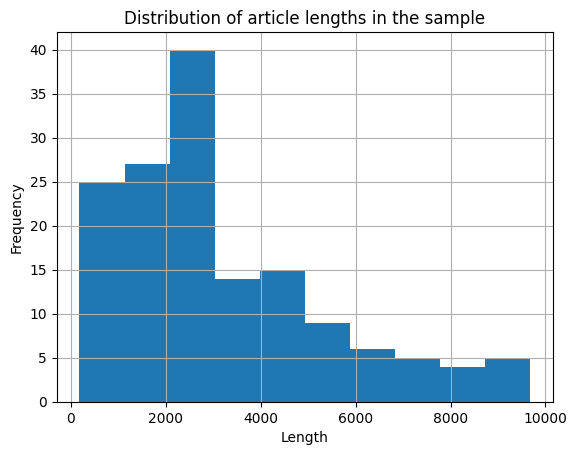

In [4]:
articles_sample.text.str.len().hist()
import matplotlib.pyplot as plt
plt.title("Distribution of article lengths in the sample")
plt.xlabel("Length")
plt.ylabel("Frequency")
plt.show()

In [5]:
# use dspy for generation
# there is a sglang server at port 7501, it has llama3.1 8b running
import dspy

lm = dspy.LM("openai/meta-llama/Llama-3.1-8B-Instruct",
             api_base="http://localhost:7501/v1",  # ensure this points to your port
             api_key="local", 
             model_type='chat')

dspy.configure(lm=lm)

dspy.settings.lm.dump_state()

{'model': 'openai/meta-llama/Llama-3.1-8B-Instruct',
 'model_type': 'chat',
 'cache': True,
 'cache_in_memory': True,
 'num_retries': 8,
 'finetuning_model': None,
 'launch_kwargs': {},
 'train_kwargs': {},
 'temperature': 0.0,
 'max_tokens': 1000,
 'api_base': 'http://localhost:7501/v1',
 'api_key': 'local'}

In [6]:
# system prompt
system_prompt = """
You are an expert fact generator. You are given a news article and, based on the content, you will generate a few verifiable factual claims.
"""

simple_prompt = """
Based on the following article, generate between 1 and 3 verifiable factual claims and between 1 and 3 non-factual claims.
The factual claims should be clearly true based on the content of the article, while the non-factual claims should be false and in contrast to the content of the article.
Each claim should be able to be verified on its own and should therefore contain all the context around the claim. No claim should be vague or ambiguous or need information from the article or the other claims to be understood. Repeat the context needed in each claim, like the time of the event, the location, the person, etc. The claims should be in the same language as the article. 

Requirents for each claim:
- the claim should be verifiable on its own, without having access to the article or the other claims
- the claim should be in the same language as the article
- the claim should be clear and not ambiguous
- the claim should contain all the context needed to be understood
- the claim should be plausible
- the timeframe (and if necessary the location) should be understandable from the claim alone (if not specified in the article, use the publishing date, like "As of 2024-01-01, ...")

Before generating the claims, reason about:
- the plausibility of the claims you can generate
- the number of true and false claims you can generate
- the mix of true and false claims you can generate
- the details you should include in each claim to make it verifiable
- the draft of the claims you will generate
- checking the plausibility of the claims you will generate
- checking if the claims contain all the information needed to be verifiable, most importantly a specific timeframe 

Answer in the following format:

Reasoning:
...

Factual claims (1-3 claims):
- claim 1
- claim n

Non-factual claims (1-3 claims):
- claim 1
- claim n

Do not output any other text than the claims. Choose the number and mix of true and false claims based on the number of true and false claims you reason you can convincingly generate.

Date of publication:
{date}
Article:
{article}

"""
def parse_claims(answer):
    # split the answer into reasoning, factual and non-factual claims
    reasoning = ""
    factual_claims = []
    non_factual_claims = []
    current_section = None
    
    for line in answer.split("\n"):
        line = line.strip()
        if line == "Reasoning:":
            current_section = "reasoning"
        elif line.startswith("Factual claims"):
            current_section = "factual"
        elif line.startswith("Non-factual claims"):
            current_section = "non-factual"
        elif line and current_section:
            if current_section == "reasoning":
                reasoning += line + "\n"
            elif line.startswith(("- ", "1. ", "2. ", "3. ")):
                # Handle both bullet points and numbered lists
                claim = line.lstrip("- 123.").strip()
                if current_section == "factual":
                    factual_claims.append(claim)
                elif current_section == "non-factual":
                    non_factual_claims.append(claim)
                
    return reasoning.strip(), factual_claims, non_factual_claims


def generate_claims(article, date):
    prompt = simple_prompt.format(article=article, date=date)
    conversation=[{"role":"system", "content":system_prompt}, {"role":"user", "content":prompt}]
    answer = lm(messages=conversation, cache=False, temperature=1)
    reasoning, factual_claims, non_factual_claims = parse_claims(answer[0])
    return date, reasoning, factual_claims, non_factual_claims

publishing_date, reasoning, factual_claims, non_factual_claims = generate_claims(articles_sample.text.iloc[60], articles_sample.publishing_date.iloc[60])
publishing_date, reasoning, factual_claims, non_factual_claims 

APIError: litellm.APIError: APIError: OpenAIException - Connection error.

In [ ]:
# same but with examples from the claims dataset
def generate_claims_with_examples(article, date, claims_df):
    # Select 3 random articles
    articles = pd.Series(claims_df.total_text.unique()).sample(3)
    article_claims_overall = []
    for article_text in articles:
        # Get all claims and ratings for this article
        claims = claims_df[claims_df.total_text == article_text][['text', 'ratingName']].drop_duplicates()
        article_claims = []
        for _, claim_row in claims.iterrows():
            article_claims.append((claim_row['text'], claim_row['ratingName']))
        article_claims_overall.append((article_text, article_claims))
    # Add example claims to the prompt
    examples_text = "Here are some example claims:\n"
    for i, (article_text, article_claims) in enumerate(article_claims_overall, 1):
        examples_text += f"{i}. Article: {article_text}\n"
        for claim, rating in article_claims:
            examples_text += f"Claim: {claim}\nRating: {rating}\n"
        examples_text += "\n"
        
    # add the article to the prompt
    prompt = examples_text + simple_prompt.format(article=article, date=date)
    
    conversation=[{"role":"system", "content":system_prompt}, {"role":"user", "content":prompt}]
    answer = lm(messages=conversation, cache=False, temperature=1)
    reasoning, factual_claims, non_factual_claims = parse_claims(answer[0])
    return date, reasoning, factual_claims, non_factual_claims

# Test with examples from claims dataset
example_claims = claims.text.tolist()
publishing_date, reasoning, factual_claims, non_factual_claims = generate_claims_with_examples(
    articles_sample.text.iloc[60], 
    articles_sample.publishing_date.iloc[60],
    claims
)
publishing_date, reasoning, factual_claims, non_factual_claims

In [ ]:
claims.duplicated(subset=['text', 'total_text']).sum()

In [ ]:
dspy.inspect_history()

In [ ]:
claims.groupby('total_text').filter(lambda x: len(x) > 3)

In [ ]:
claims.head()

In [ ]:
# check claims_naive_20250326_220827.csv
claims_naive = pd.read_csv('claims_naive_20250326_220827.csv')
claims_naive.is_factual.value_counts()

In [ ]:
claims_naive.language.value_counts()

In [ ]:
## check claims_examples_20250326_221926.csv
claims_examples = pd.read_csv('claims_examples_20250326_223856.csv')
claims_examples.is_factual.value_counts()

In [ ]:
claims_examples.article_text.value_counts()

In [ ]:
import weave

In [ ]:
!pip install weave

In [ ]:
@weave.op(name="generate_claims_with_examples")
def generate_claims_with_examples(article, date, claims_df):
    # Select 3 random articles
    articles = pd.Series(claims_df.total_text.unique()).sample(3)
    article_claims_overall = []
    for article_text in articles:
        # Get all claims and ratings for this article
        claims = claims_df[claims_df.total_text == article_text][['text', 'ratingName']].drop_duplicates()
        article_claims = []
        for _, claim_row in claims.iterrows():
            article_claims.append((claim_row['text'], claim_row['ratingName']))
        article_claims_overall.append((article_text, article_claims))
    # Add example claims to the prompt
    examples_text = "Here are some example claims:\n"
    for i, (article_text, article_claims) in enumerate(article_claims_overall, 1):
        examples_text += f"{i}. Article: {article_text}\n"
        for claim, rating in article_claims:
            examples_text += f"Claim: {claim}\nRating: {rating}\n"
        examples_text += "\n"
        
    # add the article to the prompt
    prompt = examples_text + simple_prompt.format(article=article, date=date)
    
    conversation=[{"role":"system", "content":system_prompt}, {"role":"user", "content":prompt}]
    answer = lm(messages=conversation, cache=False, temperature=1)
    reasoning, factual_claims, non_factual_claims = parse_claims(answer[0])
    return date, reasoning, factual_claims, non_factual_claims


weave.init(project_name="cfgen")
generate_claims_with_examples(articles_sample.text.iloc[60], articles_sample.publishing_date.iloc[60], claims)